# Analyze imgep dataset
## Explain what are bus and ddr bandwidths

## Load datasets

In [116]:
import pickle
import numpy  as np
from exploration.load_file import load
from diversity.diversty import Diversity
import matplotlib.pyplot as plt

In [2]:
#Load data
folder = "results"
N = 100000
k=1
print_freq = 1000
name_imgep = f'{folder}/imgep_bandwidth_N_{N}_k_{k}'
name_random = f'{folder}/random_bandwidth_expl_N_{N}'
content_imgep = load(name_imgep)
content_imgep_tab = content_imgep['numpy_view']
content_random = load(name_random)
content_random_tab = content_random['numpy_view']
dim_out = 18
#Compute diversity
##################################
min_tab = np.zeros((dim_out,))
max_tab = np.ones((dim_out,))*10



results/imgep_bandwidth_N_100000_k_1_1.pkl
results/random_bandwidth_expl_N_100000_2.pkl


In [3]:
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_imgep_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_random_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]

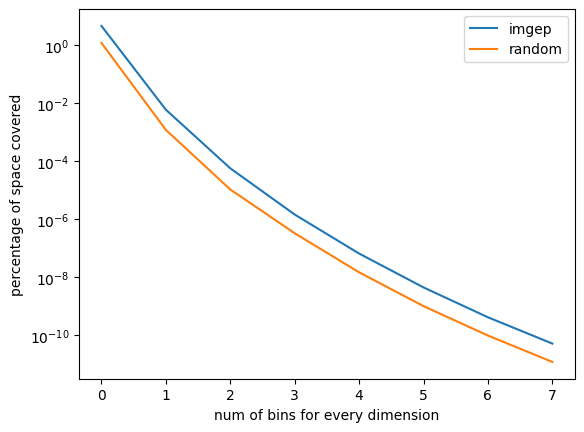

In [4]:
plt.semilogy(diversity_imgep_list,label='imgep')
plt.semilogy(diversity_random_list,label='random')
plt.ylabel('percentage of space covered')
plt.xlabel('num of bins for every dimension')
plt.legend()

In [5]:
list(range(10,100,10))

[10, 20, 30, 40, 50, 60, 70, 80, 90]

In [6]:
step = 1000
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_imgep_tab[:step]) for step in range(step,N+1,step)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_random_tab[:step]) for step in range(step,N+1,step)]

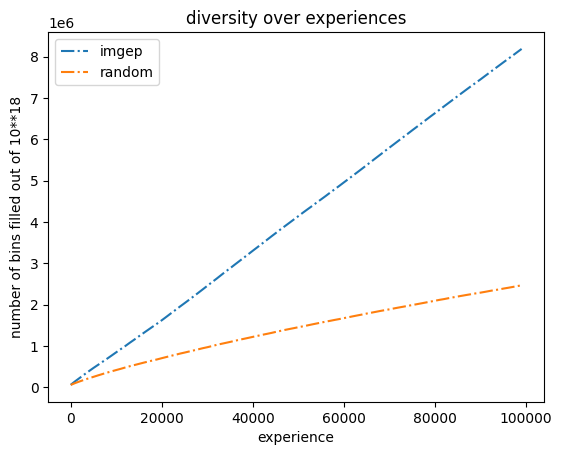

In [7]:

#print(f'diversity imgep {diversity_(content_imgep_tab)}/10**{dim_out}')
#print(f'diversity random {diversity_(content_random_tab)}/10**{dim_out}')
plt.figure()
plt.plot(range(0,N,print_freq),diversity_imgep_list,'-.',label="imgep")
plt.plot(range(0,N,print_freq),diversity_random_list,'-.',label="random")
plt.legend()
plt.title('diversity over experiences')
plt.xlabel('experience')
plt.ylabel(f'number of bins filled out of 10**{dim_out}')
plt.show()

In [8]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

## Attempt to identify clusters with UMAP
**Remarks**

* Projection with inferior dimension do not allow to discriminate consistent poles


In [199]:
##Attempt to reduce dimension - UMAP
import umap
from sklearn.cluster import HDBSCAN
#######################################################

from sklearn.preprocessing import StandardScaler


data = np.array(content_imgep['numpy_view'])
#min max norm
print('data shape', data.shape)
print('min data',data.min(axis=0).shape)
data = (data - data.min(axis=0))/(1+ data.max(axis=0) - data.min(axis=0))
#data = StandardScaler().fit_transform(data)
reducer = umap.UMAP(n_components=6,metric="euclidean")
embedding = reducer.fit_transform(data)

data shape (100000, 18)
min data (18,)


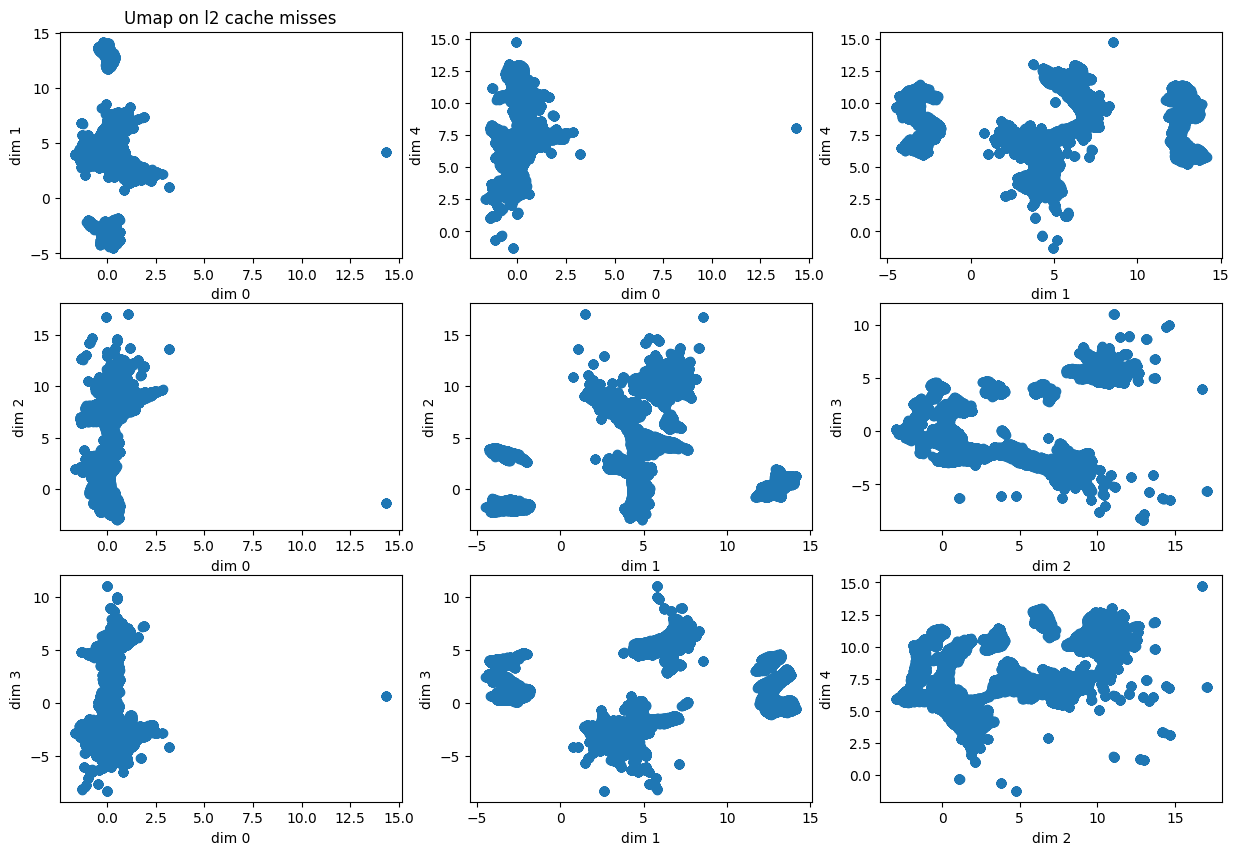

In [200]:
idx = [(i,j) for i in range(j) for j in range(i+1,5)]
fig,axs=plt.subplots(3,3,figsize=(15,10))

for j in range(9):
    axs[j%3,j//3].scatter(embedding[:,idx[j][0]],embedding[:,idx[j][1]])
    axs[j%3,j//3].set_xlabel(f'dim {idx[j][0]}')
    axs[j%3,j//3].set_ylabel(f'dim {idx[j][1]}')
    if j==0:
        axs[j%2,j//2].set_title('Umap on l2 cache misses')
plt.show()

In [201]:
hdb = HDBSCAN(copy=True, min_cluster_size=400)
hdb.fit(embedding)
print('hdb labels:',hdb.labels_)
print('labels',np.unique(hdb.labels_))

hdb labels: [ 6  6 -1 ...  3  3  3]
labels [-1  0  1  2  3  4  5  6  7  8  9]


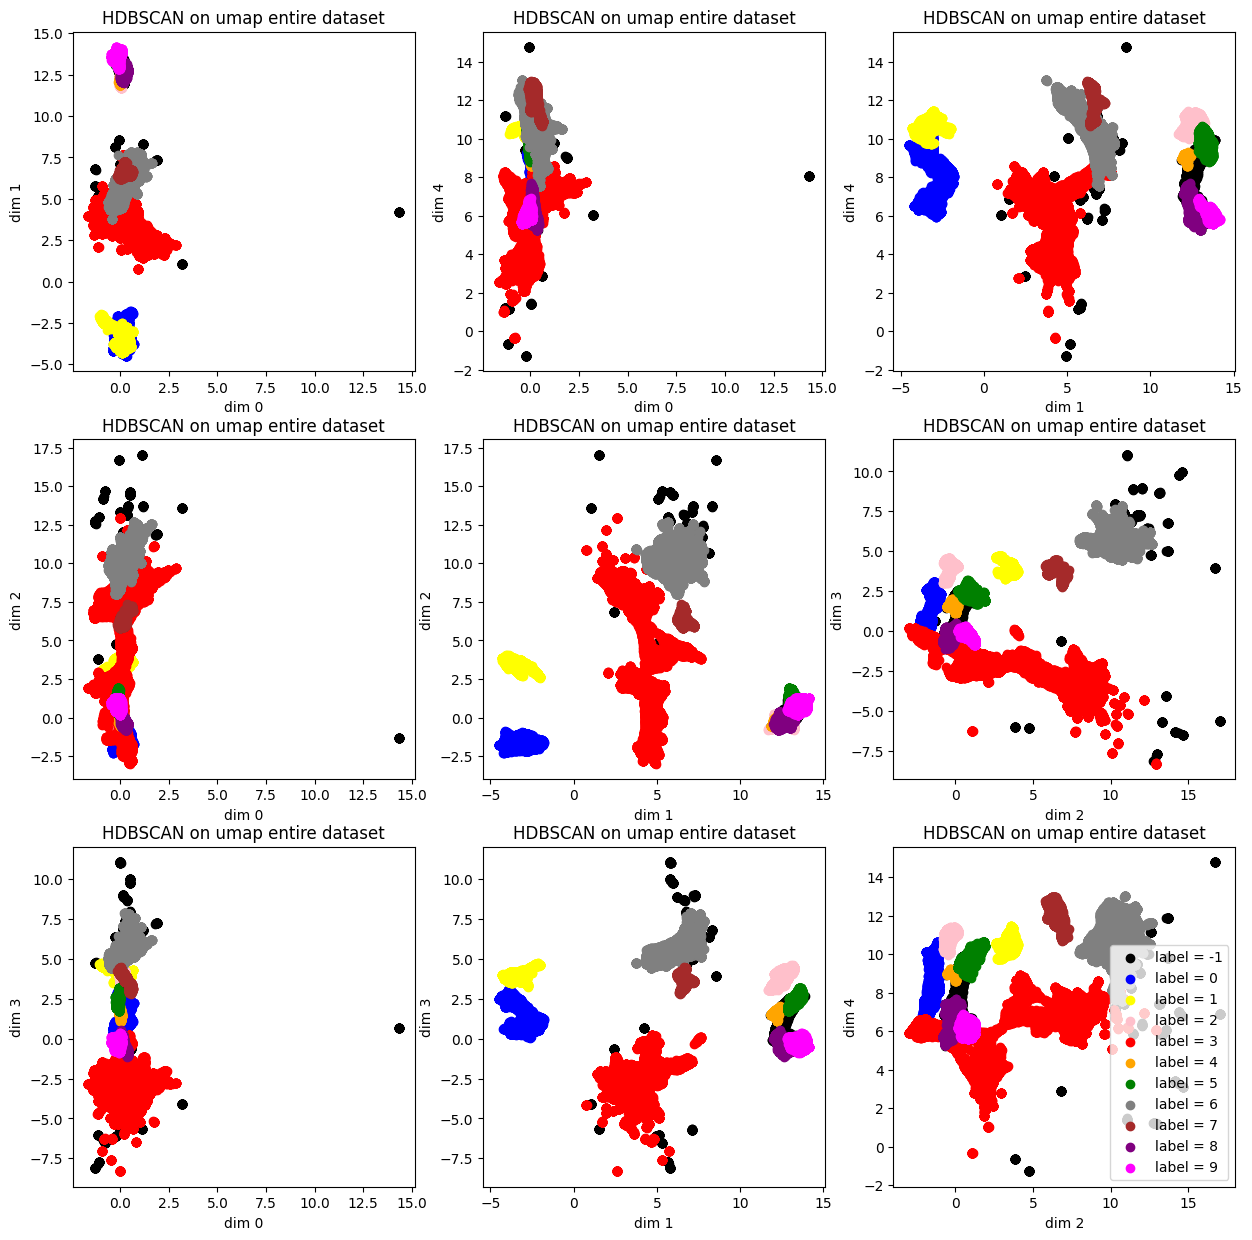

num elem label -1: 2484
num elem label 0: 10484
num elem label 1: 4599
num elem label 2: 3081
num elem label 3: 47304
num elem label 4: 745
num elem label 5: 4412
num elem label 6: 18634
num elem label 7: 2884
num elem label 8: 2256
num elem label 9: 3117


In [202]:
data_list = {key:[] for key in np.unique(hdb.labels_)}   
for j in range(N):
        data_list[hdb.labels_[j]].append(embedding[j])
fig,axs=plt.subplots(3,3,figsize=(15,15))
for i in range(9):
    for j,key in enumerate(data_list):
        axs[i%3,i//3].scatter(np.array(data_list[key])[:,idx[i][0]],np.array(data_list[key])[:,idx[i][1]],color = ['black','blue','yellow','pink','red','orange','green','gray','brown','purple','magenta'][j],label=f'label = {key}')
        axs[i%3,i//3].set_title('HDBSCAN on umap entire dataset')
        axs[i%3,i//3].set_xlabel(f'dim {idx[i][0]}')
        axs[i%3,i//3].set_ylabel(f'dim {idx[i][1]}')
plt.legend()
plt.show()
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')

## Cluster Analysis

In [21]:
clusters_imgep = {key:{feature:[] for feature in content_imgep['memory_observation'].keys()} for key in np.unique(hdb.labels_)}   
for j in range(N):
        for feature in content_imgep['memory_observation']:
            clusters_imgep[hdb.labels_[j]][feature].append(content_imgep['memory_observation'][feature][j])

[ 0.00109379 -0.10735576  0.62264151 -0.23582171 -0.21449275  0.0348373 ]
[0.03769263 0.71218392 2.10537583 2.93822215 1.19836639 0.41603153]


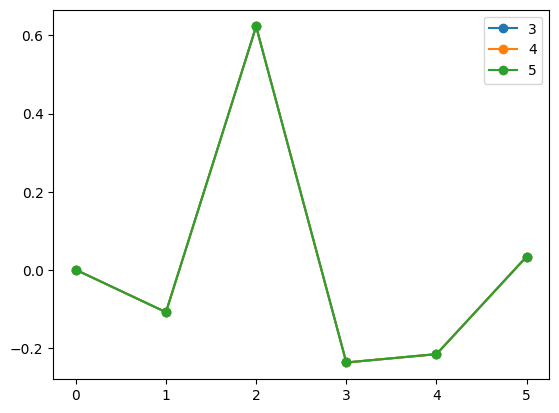

In [35]:

print(a.mean(axis=0))
print(a.std(axis=0))
for j in range(3,6):
    a = np.array(clusters_imgep[hdb.labels_[j]]['bus_bandwidth_core_0_diff'])
    plt.plot(a.mean(axis=0),'-o',label=j)
    plt.legend()
plt.show()


In [189]:
import pandas as pd

j =4
dic_cluster_2_corr = {}

feature_list = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_diff']
for cluster in (range(6)):
    list_df = []
    for time in range(6):
        df = pd.DataFrame([])
        for feature in feature_list:
            if feature =='time_core0_diff':
                 df[feature] = np.array(clusters_imgep[cluster]['time_core0_core1']) - np.array(clusters_imgep[cluster]['time_core0_iso'])
            else:
                df[feature] = np.array(clusters_imgep[cluster][feature])[:,time]
        list_df.append(df.corr())
    dic_cluster_2_corr[cluster] = list_df
#np.array(clusters_imgep[hdb.labels_[j]]['bus_bandwidth_core_0_diff']).shape

In [196]:
dic_cluster_2_corr.keys()

dict_keys([0, 1, 2, 3, 4, 5])

In [193]:
dic_cluster_2_corr[1][4].values.round(2)

array([[ 1.  ,  0.59,  0.11,  0.2 ],
       [ 0.59,  1.  , -0.01,  0.26],
       [ 0.11, -0.01,  1.  , -0.02],
       [ 0.2 ,  0.26, -0.02,  1.  ]])

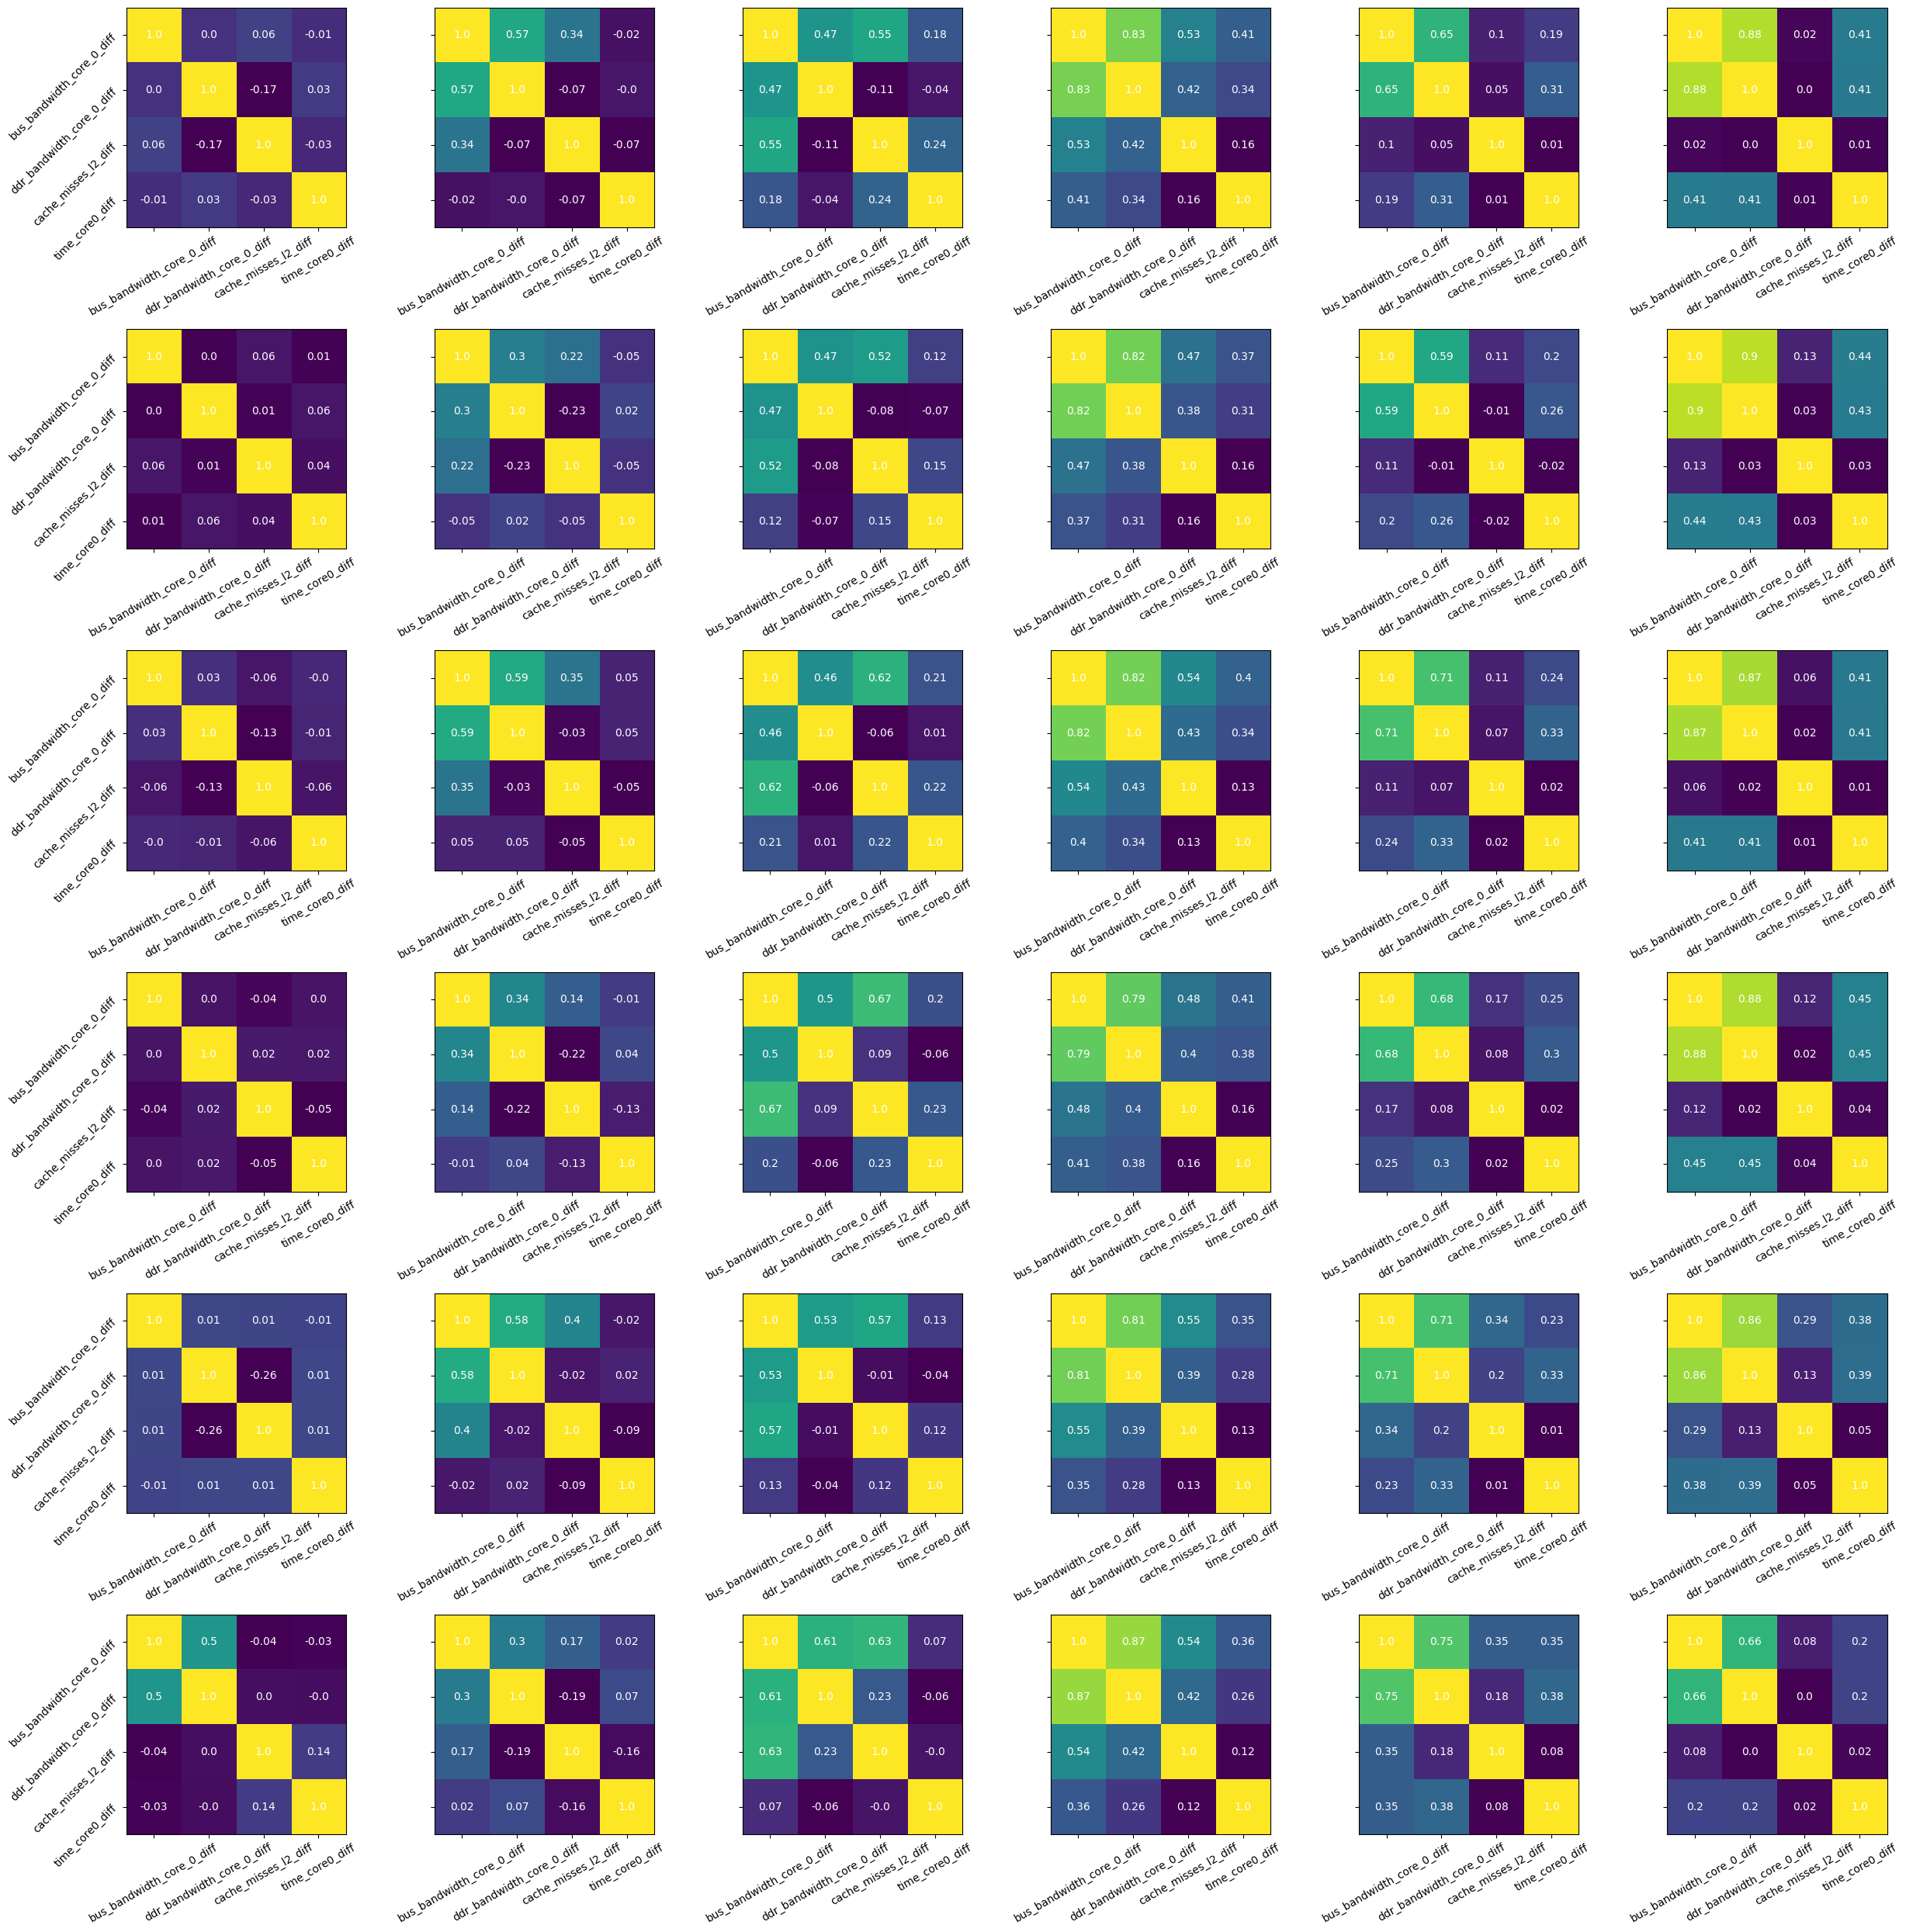

In [205]:
fig, axs = plt.subplots(6, 6, figsize=(25, 25),sharey=True,sharex=False)
for time in range(6):
    for clust in range(6):
        # Show all ticks and label them with the respective list entries
        axs[clust,time].imshow(dic_cluster_2_corr[clust][time])
        axs[clust,time].set_xticks(range(len(feature_list)), labels=feature_list,rotation=30)
        axs[clust,time].set_yticks(range(len(feature_list)), labels=feature_list,rotation=45)
        
        # Loop over data dimensions and create text annotations.
        for i in range(len(feature_list)):
            for j in range(len(feature_list)):
                text = axs[clust,time].text(j, i, dic_cluster_2_corr[clust][time].values.round(2)[i, j],ha="center", va="center", color="w")
        ax.set_title("Harvest of local farmers (in tons/year)")
fig.tight_layout()
plt.show()

In [118]:
im, _ = heatmap(list_df[2], feature_list,feature_list, ax=ax,
                cmap="Wistia", cbarlabel="harvest [t/year]")
plt.show()

In [18]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

In [90]:
allongement_mean = {}
list_features = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_diff']
for feature in list_features:
    allongement_mean[feature] = []
    for j in np.unique(hdb.labels_):
        if feature =='time_core0_diff':
            allongement = np.array(clusters_imgep[j]['time_core0_core1']) - np.array(clusters_imgep[j]['time_core0_iso'])
        else:
            allongement = np.array(clusters_imgep[j][feature])
        #break
        if feature!='time_core0_diff':
            mean_allongement = np.mean(allongement,axis=0)
        else:
            mean_allongement = np.mean(allongement)# a revoir, la matrice est trop grande et on perd de l'information
        allongement_mean[feature].append(mean_allongement)

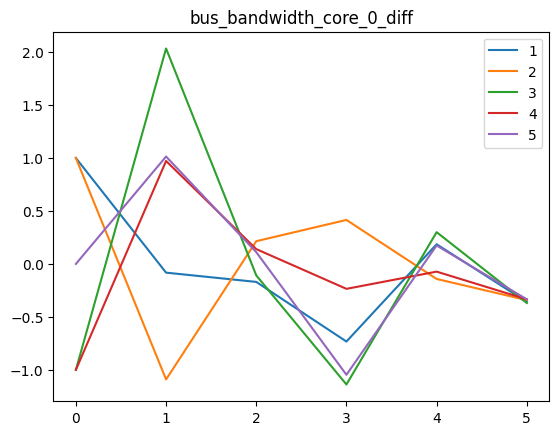

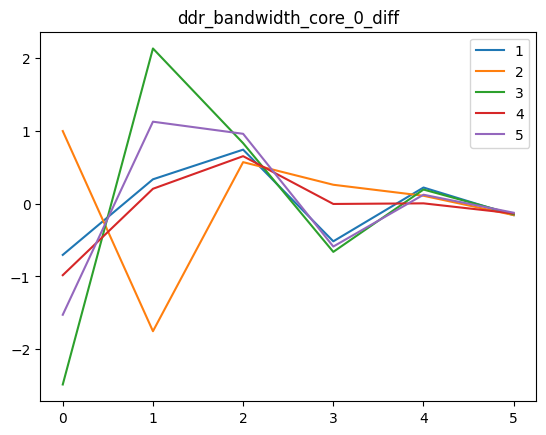

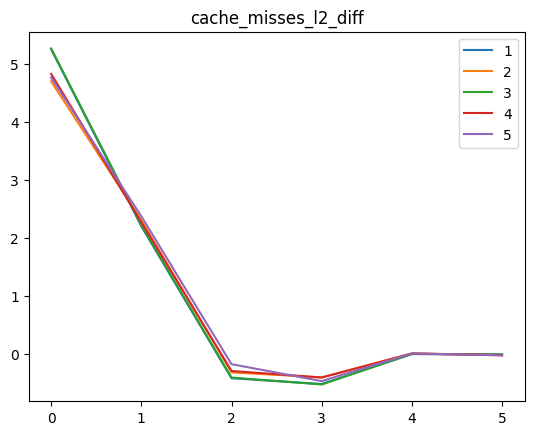

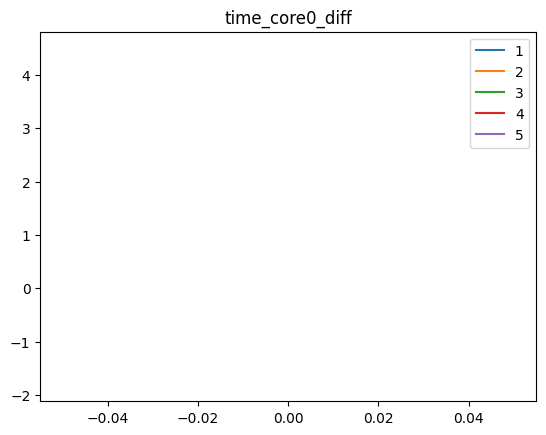

In [206]:
plt.figure()
for feature in ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_diff']:
    for j in range(1,6):
        plt.plot(allongement_mean[feature][j],label=j)
        plt.legend()
        plt.title(feature)
    plt.show()

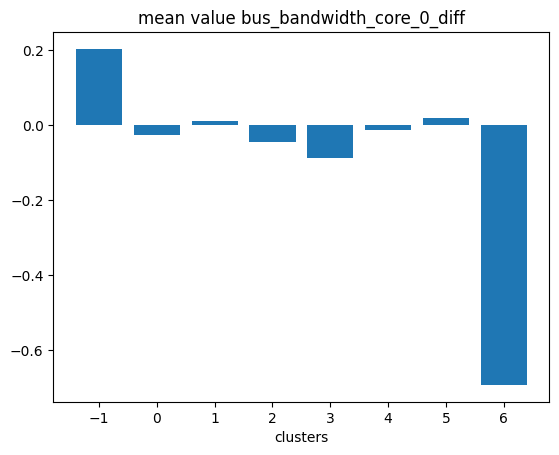

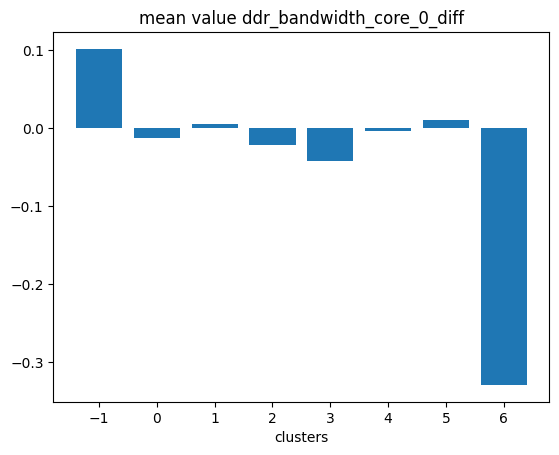

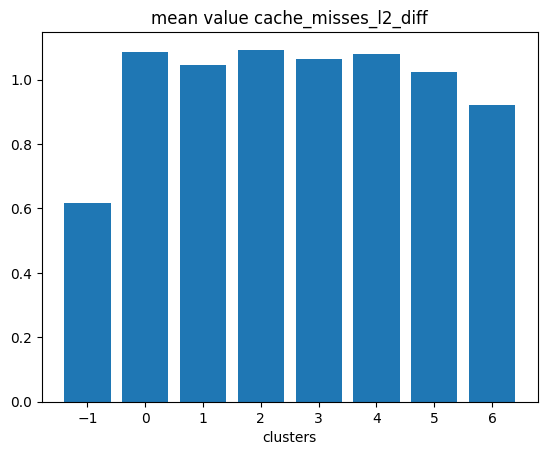

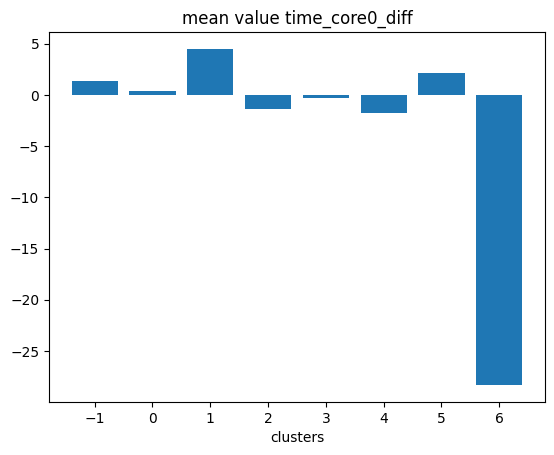

In [59]:
for feature in list_features:
    plt.figure()
    plt.bar(np.unique(hdb.labels_),allongement_mean[feature])
    plt.title('mean value '+feature)
    plt.xlabel('clusters')


### Some clusters seem too appear
### Observe correlations matrix for each group
#### try to observe correlation between the attacker metrics and the timing impact ? 

## Attempt to identify clusters with Kmeans on untouched simulator data
--> sklearn website to
"Silhouette analysis can be used to study the separation distance between the resulting clusters. The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like number of clusters visually. This measure has a range of [-1, 1].

Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster."

In [203]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
for n_clusters in range(2,6):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(data)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(data, labels)
    print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    silhouette_avg,
    )

KeyboardInterrupt: 

### --> the values indicate pool clusters as they are far from 1.

# essayer critere elbow pour montrer qu'on ne tire pas grand chose de clusters